In [3]:
import pandas as pd
df = pd.read_csv("data set.csv")
df.head(50)


,Order_ID,Customer_ID,Order_Date,Order_Time,City,Area,Restaurant,Food_Item,Category,Quantity,Price,Delivery_Time_Min,Payment_Mode,Rating
0,O1,C7116,2025-03-04,00:06,Salem,Porur,Burger King,Dosa,Veg,4,325,38,Card,5.0
1,O2,C6623,2025-11-13,17:05,Trichy,Porur,KFC,Fried Rice,Non-Veg,5,232,18,UPI,3.5
2,O3,C4463,2025-05-11,04:21,Coimbatore,Velachery,SS Hyderabad,Parotta,Non-Veg,3,286,33,Cash,4.7
3,O4,C9648,2025-02-26,14:16,Salem,Velachery,Burger King,Sandwich,Veg,2,491,46,Cash,3.0
4,O5,C1307,2025-08-09,03:36,Salem,Anna Nagar,Dominos,Sandwich,Veg,4,321,26,Cash,4.4
5,O6,C4778,2025-02-07,19:53,Salem,Porur,A2B,Meals,Veg,4,122,30,Cash,4.0
6,O7,C1149,2025-12-31,14:17,Chennai,Velachery,A2B,Noodles,Non-Veg,4,378,49,Card,4.1
7,O8,C2330,2025-01-02,07:45,Trichy,Velachery,KFC,Fried Rice,Non-Veg,5,101,49,Card,3.9
8,O9,C6884,2025-08-09,15:55,Chennai,T Nagar,Dominos,Sandwich,Non-Veg,4,158,60,UPI,3.9
9,O10,C5106,2025-12-03,03:31,Coimbatore,Velachery,Dominos,Dosa,Veg,3,156,34,UPI,4.1


In [4]:
df.tail(8)

,Order_ID,Customer_ID,Order_Date,Order_Time,City,Area,Restaurant,Food_Item,Category,Quantity,Price,Delivery_Time_Min,Payment_Mode,Rating
4992,O4993,C7542,2025-03-14,14:23,Trichy,Velachery,SS Hyderabad,Biryani,Non-Veg,5,289,22,UPI,4.4
4993,O4994,C7847,2025-01-19,22:24,Coimbatore,Velachery,Dominos,Pizza,Non-Veg,2,367,22,Card,4.7
4994,O4995,C8454,2025-08-19,03:11,Trichy,Velachery,SS Hyderabad,Parotta,Non-Veg,3,282,44,Card,4.2
4995,O4996,C8643,2025-01-01,05:08,Trichy,T Nagar,KFC,Meals,Veg,5,387,59,Card,4.8
4996,O4997,C2519,2025-11-25,02:45,Salem,Anna Nagar,Dominos,Parotta,Veg,4,451,53,UPI,4.8
4997,O4998,C8876,2025-08-19,03:06,Coimbatore,Velachery,Dominos,Fried Rice,Veg,3,362,44,Cash,4.4
4998,O4999,C5284,2025-03-17,22:08,Trichy,T Nagar,SS Hyderabad,Meals,Non-Veg,4,374,15,UPI,4.3
4999,O5000,C4772,2025-11-15,08:13,Trichy,Porur,SS Hyderabad,Noodles,Non-Veg,2,280,55,Cash,3.6


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order_ID           5000 non-null   object 
 1   Customer_ID        5000 non-null   object 
 2   Order_Date         5000 non-null   object 
 3   Order_Time         5000 non-null   object 
 4   City               5000 non-null   object 
 5   Area               5000 non-null   object 
 6   Restaurant         5000 non-null   object 
 7   Food_Item          5000 non-null   object 
 8   Category           5000 non-null   object 
 9   Quantity           5000 non-null   int64  
 10  Price              5000 non-null   int64  
 11  Delivery_Time_Min  5000 non-null   int64  
 12  Payment_Mode       5000 non-null   object 
 13  Rating             5000 non-null   float64
dtypes: float64(1), int64(3), object(10)
memory usage: 547.0+ KB


In [6]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Order_Time', 'City', 'Area',
       'Restaurant', 'Food_Item', 'Category', 'Quantity', 'Price',
       'Delivery_Time_Min', 'Payment_Mode', 'Rating'],
      dtype='object')

In [7]:
df.describe()

,Quantity,Price,Delivery_Time_Min,Rating
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,2.985200,290.884800,37.517000,4.005200
std,1.400348,120.544389,13.396388,0.583837
min,1.000000,80.000000,15.000000,3.000000
25%,2.000000,185.750000,26.000000,3.500000
50%,3.000000,291.000000,37.000000,4.000000
75%,4.000000,395.000000,49.000000,4.500000
max,5.000000,500.000000,60.000000,5.000000


In [8]:
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Order_Date,0
Order_Time,0
City,0
Area,0
Restaurant,0
Food_Item,0
Category,0
Quantity,0


Total revenue


In [9]:
df["Revenue"] = df["Quantity"] * df["Price"]
total_revenue = df["Revenue"].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 4334086


Peak order times

In [10]:
customert_spending=df.groupby("Customer_ID")["Revenue"].sum().sort_values(ascending=False)
print(customert_spending)

Customer_ID
C3487    5996
C7759    5785
C7706    5265
C1763    5035
C6261    4955
         ... 
C4165      84
C1626      84
C3340      83
C6235      82
C2732      81
Name: Revenue, Length: 3863, dtype: int64


In [11]:
df["Hour"] = pd.to_datetime(df["Order_Time"]).dt.hour
peak_hours = df["Hour"].value_counts().sort_values(ascending=False)
print(peak_hours.head())

Hour
4     237
9     235
17    227
14    226
12    220
Name: count, dtype: int64


/tmp/ipykernel_785/3717361710.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Order_Time"]).dt.hour


Most popular Dishes

In [12]:
popular_dishes=df["Food_Item"].value_counts()
print(popular_dishes.head(10))

Food_Item
Burger        527
Dosa          511
Biryani       507
Sandwich      507
Pizza         507
Parotta       496
Meals         490
Chicken 65    489
Noodles       487
Fried Rice    479
Name: count, dtype: int64


Food category analysis

In [13]:
category_anlalysis=df.groupby("Category")["Revenue"].sum()
print(category_anlalysis)

Category
Non-Veg    2216799
Veg        2117287
Name: Revenue, dtype: int64


Restaurant performance

In [14]:
restaurant_performance=df.groupby("Restaurant")["Revenue"].sum().sort_values(ascending=False)

print(restaurant_performance)

Restaurant
KFC             881939
A2B             878264
SS Hyderabad    875977
Dominos         852783
Burger King     845123
Name: Revenue, dtype: int64


City-Wise Analysis

In [15]:
city_analysis=df.groupby("City")["Revenue"].sum().sort_values(ascending=False)
print(city_analysis)

City
Trichy        905282
Salem         889503
Chennai       870570
Coimbatore    847995
Madurai       820736
Name: Revenue, dtype: int64


Customer Spending Analysis

In [16]:
customer_spending=df.groupby("Customer_ID")["Revenue"].sum().sort_values(ascending=False)
print(customer_spending.head(10))

Customer_ID
C3487    5996
C7759    5785
C7706    5265
C1763    5035
C6261    4955
C7426    4737
C1706    4685
C1819    4639
C1033    4586
C3066    4572
Name: Revenue, dtype: int64


Payment Method Analysis


In [17]:
payment__analysis=df["Payment_Mode"].value_counts()
print(payment__analysis)

Payment_Mode
Cash    1679
Card    1670
UPI     1651
Name: count, dtype: int64


Delivery Perfomance

In [18]:
avg_delivery = df["Delivery_Time_Min"].mean()
print("Average Delivery Time:",avg_delivery)

Average Delivery Time: 37.517


Customer Ratings Analysis

In [19]:
#Average Rating
avg_rating = df["Rating"].mean()

print("Average Rating:",round(avg_rating,2))

#Rating Distribution
rating_distribution = df["Rating"].value_counts().sort_index()

print(rating_distribution)

Average Rating: 4.01
Rating
3.0    128
3.1    252
3.2    251
3.3    250
3.4    258
3.5    255
3.6    215
3.7    242
3.8    270
3.9    253
4.0    223
4.1    255
4.2    240
4.3    254
4.4    240
4.5    271
4.6    235
4.7    254
4.8    259
4.9    254
5.0    141
Name: count, dtype: int64


Discount Analysis

In [26]:
import numpy as np

df["Discount"] = np.random.randint(0, 101, size=len(df))

# Total Discount Given
total_discount = df["Discount"].sum()

print("Total Discount:", total_discount)

# Average Discount
avg_discount = df["Discount"].mean()

print("Average Discount:", round(avg_discount,2))

Total Discount: 251761
Average Discount: 50.35


calculate Average

In [25]:
df["Revenue"] = df["Quantity"] * df["Price"]
Average_Spending = df.groupby("Customer_ID")["Revenue"].sum().mean()

print("Average Spending:",round(Average_Spending,2))

Average Spending: 1121.95


Order Status Analysis



Order Status Count:
Category
Non-Veg    2563
Veg        2437
Name: count, dtype: int64

Order Status Percentage:
Category
Non-Veg    51.26
Veg        48.74
Name: proportion, dtype: float64


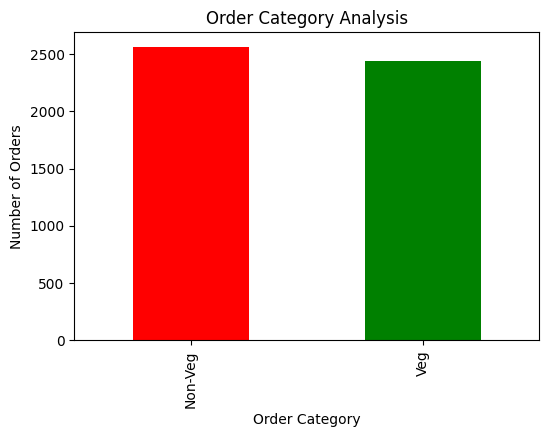

In [27]:
# Count orders by status
status_count = df["Category"].value_counts()

print("Order Status Count:")
print(status_count)

# Percentage of each status
status_percentage = (df["Category"].value_counts(normalize=True) * 100)

print("\nOrder Status Percentage:")
print(status_percentage.round(2))

import matplotlib.pyplot as plt

status_count = df["Category"].value_counts()

plt.figure(figsize=(6,4))
status_count.plot(kind="bar",color = ["red","green"])
plt.title("Order Category Analysis")
plt.xlabel("Order Category")
plt.ylabel("Number of Orders")
plt.show()

Customer Age vs Spending Analysis

In [28]:
import numpy as np
import pandas as pd

# Generate a synthetic 'Customer_Age' column since it's missing
df['Customer_Age'] = np.random.randint(18, 70, size=len(df))

df["Revenue"] = df['Quantity'] * df['Price']

age_spending = df.groupby("Customer_Age")["Revenue"].mean()

print(age_spending)

bins = [18, 30, 40, 50, 60, 100]
labels = ["18-29", "30-39", "40-49", "50-59", "60+"]

df["Age_Group"] = pd.cut(df["Customer_Age"], bins=bins, labels=labels, right=False)

age_group_spending = df.groupby("Age_Group")["Revenue"].mean()

print(age_group_spending)

Customer_Age
18    875.000000
19    831.857143
20    839.941748
21    844.577778
22    849.831683
23    854.306931
24    886.315789
25    863.725490
26    884.303371
27    886.376344
28    818.494737
29    896.692308
30    877.839623
31    821.692308
32    924.283333
33    844.971698
34    925.469136
35    837.109756
36    923.626374
37    923.879121
38    832.606061
39    918.886792
40    893.962264
41    880.705882
42    926.184783
43    769.493506
44    959.444444
45    919.413223
46    751.657143
47    883.340426
48    776.663158
49    857.032609
50    895.720930
51    909.413043
52    860.412844
53    864.482759
54    766.086207
55    809.695652
56    892.990654
57    896.915888
58    930.107843
59    880.900990
60    826.891566
61    884.689655
62    876.165049
63    870.865979
64    898.923077
65    802.265306
66    788.425287
67    898.876404
68    825.215909
69    892.333333
Name: Revenue, dtype: float64
Age_Group
18-29    861.063629
30-39    883.725591
40-49    864.571719
50-

/tmp/ipykernel_785/1722750076.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_spending = df.groupby("Age_Group")["Revenue"].mean()


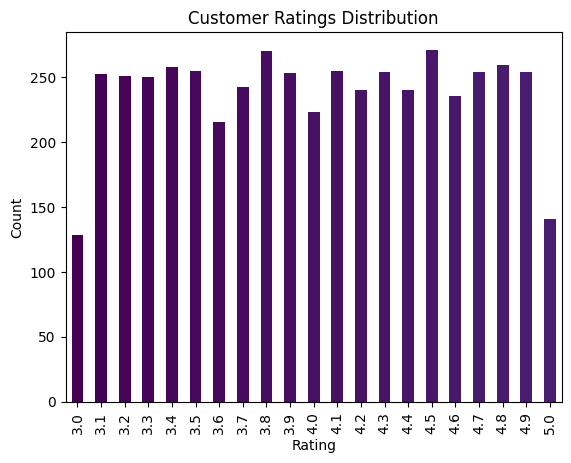

In [30]:
import matplotlib.pyplot as plt

# Get the value counts and sort by index for consistent plotting
rating_counts = df["Rating"].value_counts().sort_index()

# Determine the number of unique ratings to set the colormap's number of colors
num_ratings = len(rating_counts)

# Use a colormap to generate a sequence of colors
colors = plt.cm.viridis(range(num_ratings))

rating_counts.plot(kind="bar", color=colors)

plt.title("Customer Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

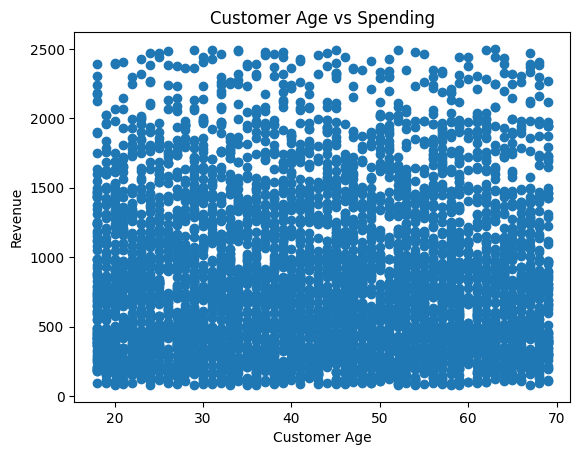

In [31]:
plt.scatter(
    df["Customer_Age"],
    df["Revenue"]
)

plt.title("Customer Age vs Spending")
plt.xlabel("Customer Age")
plt.ylabel("Revenue")
plt.show()